# 기술통계

기술통계<font size='2'>descriptive statistics</font>는 수집된 데이터의 특성을 요약하고 설명하는 통계 기법이다. 데이터를 대표하는 값(평균값, 중앙값, 최빈값)과 데이터의 퍼짐 정도를 나타내는 값(분산, 표준편차, 범위, 사분범위) 등을 통해 데이터의 전반적인 특성을 파악한다.

기술통계는 크게 두 가지 범주로 나뉜다.

- 중심 경향성: 데이터 전체를 하나의 대표값으로 요약한다.
  - 평균값<font size='2'>mean</font>: 모든 값의 합을 데이터 개수로 나눈 값. 극단적인 값(이상치)에 민감하다.
  - 중앙값<font size='2'>median</font>: 데이터를 크기 순으로 정렬했을 때 가운데 위치하는 값. 이상치의 영향을 별로 받지 않는다.
  - 최빈값<font size='2'>mode</font>: 데이터에서 가장 빈번하게 등장하는 값. 범주형 데이터에도 적용 가능하다.

- 산포도: 데이터가 중심 값 주위에 얼마나 퍼져 있는지를 나타낸다.
  - 범위<font size='2'>range</font>: 최댓값과 최솟값의 차이. 계산이 간단하지만 이상치에 취약하다.
  - 분산<font size='2'>variance</font>: 각 값과 평균의 차이(편차)를 제곱하여 평균한 값.
  - 표준편차<font size='2'>standard deviation</font>: 분산의 제곱근. 데이터와 동일한 단위를 가지며 가장 널리 쓰이는 산포 측도이다.
  - 사분범위<font size='2'>interquartile range, IQR</font>: 제3사분위수(Q3)에서 제1사분위수(Q1)를 뺀 값. 중간 50% 데이터의 퍼짐 정도를 나타내며 이상치에 강건하다.

기술통계는 데이터 분석의 첫 단계로서, 탐색적 데이터 분석<font size='2'>EDA</font>의 핵심 요소다.

**기본 설정**

EDA에 필요한 핵심 라이브러리를 불러온다.

- `numpy`: 수치 연산
- `pandas`: 데이터프레임 기반 데이터 처리
- `matplotlib.pyplot`: 데이터 시각화

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

데이터프레임 내 부동소수점을 소수점 이하 6자리까지만 출력하도록 지정한다.

In [2]:
pd.set_option('display.precision', 6)

**데이터 저장소**

In [3]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

## 데이터셋 불러오기

`body_info.csv` 파일은 성인 남녀 1,000명(여성 500명, 남성 500명)의 신체 정보를 담고 있으며, 6개의 특성(변인)으로 구성된다.

| 특성 | 설명 | 타입 |
|------|------|------|
| `ID` | 샘플 고유 식별자 (F001~F500: 여성, M001~M500: 남성) | 문자열 |
| `Sex` | 성별 (F: 여성, M: 남성) | 범주형 |
| `Age` | 나이 (세) | 수치형 |
| `Height` | 키 (cm) | 수치형 |
| `Weight` | 몸무게 (kg) | 수치형 |
| `Body fat percentage` | 체지방률 (%) | 수치형 |

아래 그림은 데이터셋에 포함된 처음 10개 데이터와 헤더를 보여준다.

<div align="center">
    <img src="https://raw.githubusercontent.com/codingalzi/code-workout-datasci/master/images/body_info.png" width="400">
</div>

`ID` 특성을 행 인덱스로 지정하면서 데이터셋을 데이터프레임으로 불러온다.

In [4]:
body_info = pd.read_csv("./data/body_info_with_outliers.csv", index_col='ID')

불러온 데이터프레임의 처음과 끝을 확인한다.
여성 데이터 500개가 앞쪽에 위치한다.

In [5]:
body_info.head()

,Sex,Age,Height,Weight,Body fat percentage
ID,,,,,
F001,F,37.0,161.4,62.9,32.8
F002,F,26.0,168.1,56.1,31.5
F003,F,39.0,163.4,53.2,25.2
F004,F,30.0,164.1,49.4,21.8
F005,F,44.0,152.9,51.9,24.2


남성 데이터 500개는 뒷쪽에 위치한다.

In [6]:
body_info.tail()

,Sex,Age,Height,Weight,Body fat percentage
ID,,,,,
M496,M,48.3,136.6,72.6,25.3
M497,M,53.2,136.3,72.4,16.1
M498,M,46.2,130.3,58.6,18.2
M499,M,34.0,138.4,52.3,15.6
M500,M,59.7,132.9,72.3,25.7


`info()` 메서드로 각 열의 데이터 타입과 결측치 여부를 확인한다.
`Sex` 특성만 문자열로 구성되었다. 즉 범주형 특성이다.
나머지 특성은 모두 부동소수점 자료형을 갖는다. 즉 수치형 특성이다.

In [7]:
body_info.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, F001 to M500
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sex                  1000 non-null   str    
 1   Age                  1000 non-null   float64
 2   Height               1000 non-null   float64
 3   Weight               1000 non-null   float64
 4   Body fat percentage  1000 non-null   float64
dtypes: float64(4), str(1)
memory usage: 51.8 KB


성별(`Sex`)과 같은 범주형 특성에 대해 `value_counts()` 메서드로 포함된 항목들의 빈도를 확인한다.
여성과 남성 정보가 각각 500개씩 포함되어 있음이 확인된다.
결과는 시리즈 객체다.

In [8]:
body_info['Sex'].value_counts()

Sex
F    500
M    500
Name: count, dtype: int64

## 데이터 대표값

주어진 데이터셋을 대표하는 값으로 평균값, 중앙값, 최빈값이 가장 많이 사용된다.

### 평균값

평균값<font size='2'>Mean</font>은 데이터를 모두 더한 뒤, 데이터의 개수로 나눈 값을 말한다.
데이터셋이 $n$ 개의 데이터 $x_1, x_2, \cdots, x_n$로 이루어져 있다면 이 데이터셋의 평균값 $\bar x$는 다음과 같이 구한다.

$$
\bar x = \frac 1 n \sum_{i=1}^{n} x_i = \frac 1 n (x_1 + x_2 + \cdots + x_n)
$$

예를 들어, 성인 남녀 1000명의 평균키는 다음과 같다.

In [9]:
body_info['Height'].mean()

np.float64(164.8657)

### 중앙값

중앙값은 데이터를 크기 순서대로 나열할 때 정확히 중앙에 위치한 값이다.

In [10]:
body_info['Height'].median()

np.float64(164.35000000000002)

### 최빈값

최빈값은 데이터에서 가장 많이 나타나는 값이다.
키 데이터처럼 연속형 데이터의 경우, 동일한 값이 여러 번 나타나는 경우가 드물 수 있다.
데이터프레임의 `mode()` 메서드를 이용하여 최빈값을 확인할 수 있다.

키의 경우 162.5와 163.1의 빈도가 가장 높다고 확인된다.

In [14]:
body_info['Height'].mode()

0    162.5
1    163.1
Name: Height, dtype: float64

`value_counts()` 메서드를 이용하면 빈도도 확인된다. 
163.9와 159.1이 각각 10번씩 가장 많이 사용되었다.

In [15]:
body_info['Height'].value_counts().iloc[:10]

Height
162.5    10
163.1    10
159.1     9
161.0     8
163.7     8
172.8     8
160.5     7
163.2     7
160.4     7
155.8     7
Name: count, dtype: int64

## 데이터 분포

### 편차

각 데이터가 평균으로부터 떨어져 있는 정도를 **편차**<font size='2'>deviation</font>라 한다.
즉, 편차는 데이터들이 평균값으로부터 떨어져 있는 정도를 나타내는 값이다.

In [16]:
deviation = body_info['Height'] - body_info['Height'].mean()
deviation

ID
F001    -3.4657
F002     3.2343
F003    -1.4657
F004    -0.7657
F005   -11.9657
         ...   
M496   -28.2657
M497   -28.5657
M498   -34.5657
M499   -26.4657
M500   -31.9657
Name: Height, Length: 1000, dtype: float64

편차의 평균값은 항상 0 임에 주의한다.
아래 코드의 결과가 0이 아닌 0에 매우 가까운 값으로 계산되는 이유는 부동소수점 연산의 한계임에 주의한다.

In [17]:
deviation.mean()

np.float64(-3.637978807091713e-15)

### 분산

앞서 보았듯이 데이터들의 편차는 항상 음수와 양수가 섞여 평균값이 0이 되기에 데이터들이 평균값을 기준으로 얼마나 떨어져 있는지를 나타내는 측정값으로는 적절치 않다.
이러한 용도로 쓰이는 값이 바로 지금부터 소개할 분산<font size='2'>variance</font>과 표준편차<font size='2'>standard deviation</font>이다.

**분산**<font size='2'>variance</font>은 편차의 제곱의 평균값이며, 계산식은 다음과 같다.

$$
S^2 = \frac 1 n \sum_{i=1}^{n} (x_i - \bar x)^2 = \frac 1 n \left\{(x_1 - \bar x)^2 + (x_2 - \bar x)^2 + \cdots + (x_n - \bar x)^2 \right \}
$$

`body_info['Height']`에 포함된 키 데이터의 분산은 편차의 제곱에 `mean()` 메서드를 적용해 구할 수 있다.

In [18]:
(deviation ** 2).mean()

np.float64(91.90567351000001)

데이터프레임의 `var()` 메서드를 활용해 구해도 된다.
하지만 데이터프레임을 이용할 때는 `ddof=0` 키워드 인자를 사용해 (편향된) 표본분산<font size='2'>sample variance</font>을 계산토록 해야한다.


In [19]:
s2 = body_info['Height'].var(ddof=0)
s2

np.float64(91.90567351000001)

`ddof` 키워드 인자를 생략하면 `ddof=1`로 지정된 기본 옵션이 실행되며
불편분산<font size='2'>unbiased variance</font>, 즉 편향되지 않은 표본분산을 계산한다.
불편분산은 편향분산<font size='2'>biased variance</font>보다 좀 더 크다.

In [20]:
body_info['Height'].var()

np.float64(91.99767118118119)

:::{note} 편향분산 vs. 불편분산

불편분산을 이해하려면 먼저 모집단과 표본 개념을 이해해야 한다.

- 모집단: 분석 대상인 모든 데이터. (ex) 성인 전체 키 데이터
- 표본: 모집단으로부터 추출한 일부 데이터. (ex) 성인 남녀 1,000명을 무작위로 선택해 얻은 키 데이터
- 모평균과 모분산: 모집단의 평균값과 분산
- 표본평균과 표본분산: 표본의 평균값과 분산

모집단 데이터는 일반적으로 구하기가 매우 어렵거나 불가능하다.
따라서 표본평균과 표본분산을 이용하여 모평균과 모분산을 추정한다.

앞서 계산한 분산은 편차의 제곱의 합을 표본의 크기 n으로 나눈 값이며 편향분산<font size='2'>biased variance</font>이라고 한다.
이유는 편차의 제곱의 합을 n이 아닌 n-1로 나눈 불편분산<font size='2'>unbiased variance</font>이 보다 모분산에 가깝다. 
실제로 불편분산의 기댓값이 모분산과 동일하다.

불편분산은 통계적으로 계산된 값을 모수, 즉 모집단의 특성을 추정하는 경우에 활용된다.
하지만 여기서는 주어진 데이터의 분포를 설명하기에 편향분산을 사용한다.

자세한 설명은 [불편추정량에 대한 고백](https://recipesds.tistory.com/entry/왜-표본분산은-n-1로-나누죠-자유도-불편추정량에-대한-고백)에서 찾아볼 수 있다.
:::

### 표준편차

분산은 편차 제곱의 평균값이므로, 데이터의 단위가 다르다.
따라서 동일한 단위로 데이터의 분포도를 측정하는 용도로 분산의 제곱근인 **표준편차**<font size='2'>standard deviation</font>를 활용한다.

$$
S = \sqrt{S^2} = \sqrt{\frac 1 n \sum_{i=1}^{n} (x_i - \bar x)^2}
$$

데이터프레임의 `std()` 메서드를 사용하여 표준편차를 구한다.
하지만 분산의 경우처럼 `ddof=0` 옵션을 함께 지정해야 편향분산에 근거한 표준편차를 계산한다.

In [21]:
s = body_info['Height'].std(ddof=0)
s

np.float64(9.586744677417878)

불편분산에 근거한 표준편차는 다음과 같다.

In [22]:
body_info['Height'].std(ddof=1)

np.float64(9.591541647784322)

### 범위

**범위**<font size='2'>range</font>는 데이터의 최댓값과 최솟값의 차이를 가리킨다.
`body_info['Height']`에 포함된 데이터의 범위는 다음과 같이 구한다.

In [23]:
range = body_info['Height'].max() - body_info['Height'].min()
range

np.float64(76.9)

### 사분위수와 사분범위

범위는 최댓값과 최소값이 변하면 그에 따라 값이 크게 요동칠 수 있다.
따라서 데이터 분포를 이해하는 데는 범위 대신 데이터의 변화에 덜 민감한 사분위수와 사분범위가 주로 이용된다.

데이터의 하위 25%, 50%, 75%에 위치하는 값을
각각 제1사분위수(Q1), 제2사분위수(Q2), 제3사분위수(Q3)라 한다.
Q2는 앞서 살펴본 중앙값에 해당한다.
사분범위<font size='2'>interquartile range</font>는 제3사분위수에서 제1사분위수를 뺀 값으로서, 평균값을 중심으로 50%의 데이터가 모여있는 구간의 크기를 나타낸다.
아래 코드는 `body_info['Height']`의 사분범위를 계산한다.

In [24]:
Q1 = body_info['Height'].quantile(0.25)
Q3 = body_info['Height'].quantile(0.75)
IQR = Q3 - Q1
IQR

np.float64(13.324999999999989)

### 상자 그림

상자 그림은 다음 값들을 점, 선분, 직사각형 등으로 표시하는데,
그림에 표시되는 값들을 위에서부터 나열하면 다음과 같다.

- 너무 큰 이상치<font size='2'>outlier</font>에 해당하는 점들
- (Q3 + 1.5 * IQR)에 해당하는 값의 수평 선분
- Q3, Q2, Q1에 해당하는 값을 이용한 직사각형
- (Q1 - 1.5 * IQR)에 해당하는 값의 수평 선분
- 너무 작은 이상치<font size='2'>outlier</font>에 해당하는 점들

이제 데이터프레임 `summary_df`의 `boxplot()` 메서드를 이용하여 `Height` 특성에 포함된 값들을 대상으로 상자 그림을 그린다.

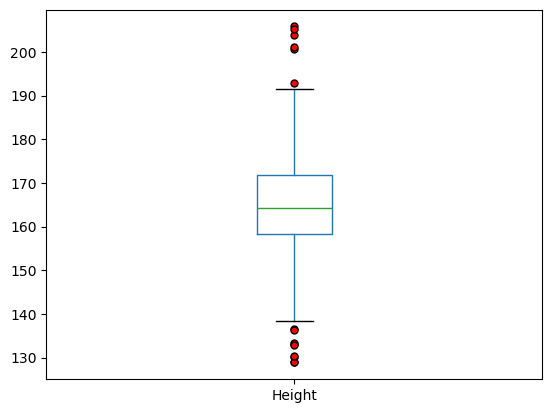

In [25]:
body_info.boxplot(
    column=['Height'],
    grid=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
)
plt.show()

### 기술통계 종합

데이터프레임의 `describe()` 메서드는
데이터의 개수, 평균값, 표준편차, 최댓값, 최소값, 사분위수에 대한 정보를 담고 있는 데이터프레임을 생성한다. 지금까지 개별적으로 살펴본 통계량을 한번에 확인할 수 있어 매우 유용하다.
단, 표준편차가 불편분산에 근거한 값임에 주의한다.

In [26]:
body_info['Height'].describe()

count    1000.000000
mean      164.865700
std         9.591542
min       128.900000
25%       158.375000
50%       164.350000
75%       171.700000
max       205.800000
Name: Height, dtype: float64

지금까지 키 데이터로 각 기술통계량의 의미와 계산 방법을 익혔다.
이제 `body_info` 데이터프레임 전체에 `describe()` 메서드를 적용하면 1000명의 모든 수치형 특성(나이, 키, 몸무게, 체지방률)에 대한 기술통계를 한번에 확인할 수 있다.

In [27]:
body_info.describe()

,Age,Height,Weight,Body fat percentage
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,47.967800,164.865700,64.239000,28.394500
std,15.170651,9.591542,11.970232,7.130178
min,20.000000,128.900000,6.000000,8.200000
25%,35.000000,158.375000,55.100000,23.400000
50%,49.000000,164.350000,62.900000,28.800000
75%,61.000000,171.700000,72.200000,33.525000
max,80.000000,205.800000,113.800000,50.500000


## 그룹별 기술통계

범주형 변수를 기준으로 그룹을 나누어 기술통계를 비교하면 데이터의 특성을 더 깊이 이해할 수 있다. `body_info` 데이터프레임은 성별(`Sex`) 변수를 포함하므로, `groupby()` 메서드를 이용하여 성별에 따른 기술통계를 비교할 수 있다.

먼저 성별에 따른 평균값을 비교한다.

In [28]:
body_info.groupby('Sex').mean(numeric_only=True)

,Age,Height,Weight,Body fat percentage
Sex,,,,
F,48.6634,158.3092,56.3924,31.9714
M,47.2722,171.4222,72.0856,24.8176


## 히스토그램

상자 그림은 사분위수와 이상치를 잘 보여주지만, 데이터의 분포 형태를 직관적으로 파악하기 어렵다. **히스토그램**<font size='2'>histogram</font>은 데이터를 구간별로 나누어 각 구간에 속하는 데이터의 개수를 막대로 표현한 그래프로, 데이터의 분포 형태를 한눈에 파악할 수 있다. 히스토그램의 구간(bins) 설정 등 상세 내용은 시각화 챕터에서 다룬다.

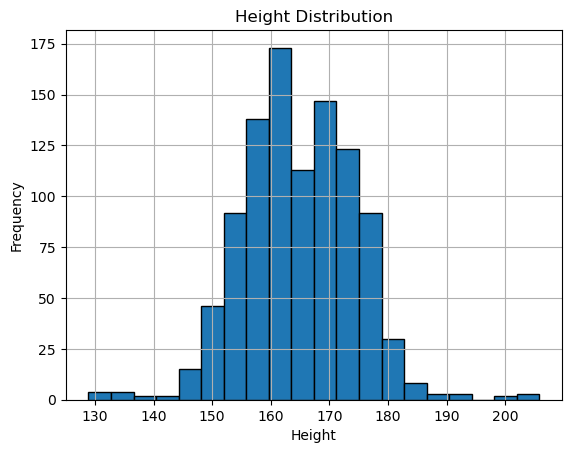

In [40]:
body_info['Height'].hist(bins=20, edgecolor='black')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.title('Height Distribution')
plt.show()

## 기술통계량 활용: 데이터 정규화

앞서 배운 기술통계량(평균, 표준편차, 최댓값, 최솟값)은 데이터를 요약하는 것 외에도 데이터를 변환하는 데 직접 활용된다. 데이터의 특성마다 단위와 범위가 다르면 직접 비교하거나 분석 모델에 함께 사용하기 어렵다. 예를 들어, 키는 150~190 범위이고 체지방률은 10~40 범위인데, 이 둘을 동일한 기준으로 비교하려면 **정규화**<font size='2'>normalization</font>가 필요하다. 대표적인 정규화 방법으로 **min-max 스케일링**과 **표준화**(z-score)가 있다.

**min-max 스케일링**

min-max 스케일링은 데이터를 0과 1 사이의 값으로 변환한다. 변환 공식은 다음과 같다.

$$
x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

`body_info`의 키 데이터에 min-max 스케일링을 적용한다.

In [41]:
height_col = body_info[['Height']]
height_minmax = (height_col - height_col.min()) / (height_col.max() - height_col.min())
height_minmax.describe()

,Height
count,1000.000000
mean,0.467694
std,0.124727
min,0.000000
25%,0.383290
50%,0.460988
75%,0.556567
max,1.000000


변환된 데이터의 최솟값은 0, 최댓값은 1이 된다.

**표준화 (z-score)**

표준화는 데이터를 평균이 0, 표준편차가 1이 되도록 변환한다. 변환 공식은 다음과 같다.

$$
z = \frac{x - \bar{x}}{S}
$$

In [42]:
height_z = (height_col - height_col.mean()) / height_col.std(ddof=0)
height_z.describe()

,Height
count,1.000000e+03
mean,-4.547474e-16
std,1.000500e+00
min,-3.751607e+00
25%,-6.770494e-01
50%,-5.379303e-02
75%,7.128906e-01
max,4.269885e+00


변환된 데이터의 평균은 0(에 매우 가까운 값), 표준편차는 1이 된다. 다음 챕터에서는 분산 개념을 두 변수 사이의 관계로 확장한 공분산과 상관계수를 살펴본다.

## 연습문제

**문제 1**

기본 데이터 저장소에 있는 `sc_weir.csv` 파일은
광주광력시에서부터 전라남도 나주를 거쳐 서해까지 이어지는 영산강에 설치된 승촌보에서 측정한 
두 종류의 데이터를 담고 있다.

- `Chl-a`: 녹조 발생의 주요 요인인 클로로필-A의 수치 100개
- `Discharge`: 보에서 방출되는 시간당 방류량 수치 100개

클로로필-A 농도가 높을 수록 수질(water quality)이 나빠지며, 방류량이 많을 수록 클로로필-A 농도는 일반적으로 떨어지며,
두 데이터 사이의 상관관계를 확인하기 위해 수집되었다.

In [43]:
sc_weir_df = pd.read_csv(data_url+'sc_weir.csv')
sc_weir_df

,Chl-a,Discharge
0,51,25
1,51,25
2,53,24
3,53,24
4,54,22
...,...,...
95,122,9
96,122,9
97,124,49
98,125,9


**데이터프레임 `values` 속성**

데이터프레임의 `values` 속성은 행과 열의 정보를 제외한 항목들로만 구성된
동일한 모양의 넘파이 어레이를 가리킨다.

In [44]:
sc_weir_arr = sc_weir_df.values

변환된 넘파이 어레이의 형태(행 수, 열 수)를 확인한다.

In [45]:
sc_weir_arr.shape

(100, 2)

처음 10개의 항목은 다음과 같다.

In [46]:
sc_weir_arr[:10]

array([[51, 25],
       [51, 25],
       [53, 24],
       [53, 24],
       [54, 22],
       [55, 22],
       [57, 21],
       [57, 21],
       [59, 20],
       [60, 20]])

(1) 방류량의 평균값을 계산하라.

답:

- 넘파이 활용

방류량은 1번 열의 데이터다.

In [47]:
discharge_arr = sc_weir_arr[:, 1]

추출한 방류량 어레이의 평균값을 계산한다.

In [48]:
np.mean(discharge_arr)

np.float64(14.93)

- 데이터프레임 활용

In [49]:
sc_weir_df['Discharge'].mean()

np.float64(14.93)

`describe()` 결과에서 `mean` 행의 `Discharge` 값을 추출하는 방법을 보인다.

In [50]:
desc = sc_weir_df.describe()
mean_desc = desc.loc['mean']
mean_desc['Discharge']

np.float64(14.93)

(2) 방류량의 중앙값을 계산하라.

- 넘파이 활용

In [51]:
np.median(discharge_arr)

np.float64(13.0)

- 데이터프레임 활용

In [52]:
sc_weir_df['Discharge'].median()

np.float64(13.0)

`describe()`의 `50%` 행에서 `Discharge`의 중앙값을 추출한다.

In [53]:
desc = sc_weir_df.describe()
median_desc = desc.loc['50%']
median_desc['Discharge']

np.float64(13.0)

(3) 방류량의 최빈값을 계산하라.

- 넘파이 활용: 지원되지 않음.

- 데이터프레임 활용

In [54]:
sc_weir_df['Discharge'].mode()

0    11
Name: Discharge, dtype: int64

최빈값 결과를 변수에 저장하여 시리즈의 타입과 구조를 살펴본다.

In [55]:
mode_desc = sc_weir_df['Discharge'].mode()

`mode()`의 반환 타입을 확인한다. 시리즈(`Series`)임을 알 수 있다.

In [56]:
type(mode_desc)

pandas.Series

시리즈의 인덱스를 확인한다.

In [57]:
mode_desc.index

RangeIndex(start=0, stop=1, step=1)

인덱스 0으로 첫 번째 최빈값을 추출한다.

In [58]:
mode_desc[0]

np.int64(11)

(4) 방류량의 제1, 제3 사분위수를 계산하라.

- 넘파이 활용

In [59]:
Q1 = np.percentile(discharge_arr, 25)
Q3 = np.percentile(discharge_arr, 75)
print(Q1, Q3, sep='\n')

11.0
16.0


- 데이터프레임 활용

In [60]:
desc.loc[['25%', '75%']]

,Chl-a,Discharge
25%,74.5,11.0
75%,114.5,16.0


(5) 클로로필-A 데이터의 범위를 계산하라.

- 넘파이 활용

클로로필-A 데이터는 0번 열이다.

In [61]:
chl_a_arr = sc_weir_arr[:, 0]

Chl-a 어레이의 최솟값, 최댓값, 범위를 계산하여 출력한다.

In [62]:
print('min:', chl_a_arr.min())
print('max:', chl_a_arr.max())
print('범위:', chl_a_arr.max() - chl_a_arr.min())

min: 51
max: 125
범위: 74


- 데이터프레임 활용

In [63]:
desc.loc[['min', 'max']]

,Chl-a,Discharge
min,51.0,9.0
max,125.0,52.0


`describe()` 결과에서 `max` - `min`으로 Chl-a의 범위를 계산한다.

In [64]:
(desc.loc['max'] - desc.loc['min']).loc['Chl-a']

np.float64(74.0)

(6) 클로로필-A 데이터의 분산을 계산하라.

- 넘파이 활용

In [65]:
np.var(chl_a_arr, ddof=0)

np.float64(506.8004000000001)

- 데이터프레임 활용

In [66]:
sc_weir_df.var(ddof=0)

Chl-a        506.8004
Discharge     40.2851
dtype: float64

Chl-a 열의 분산만 추출한다.

In [67]:
sc_weir_df.var(ddof=0).loc['Chl-a']

np.float64(506.8004000000001)

(7) 클로로필-A 데이터의 표준편차를 계산하라.

- 넘파이 활용

In [68]:
np.std(chl_a_arr,ddof=0)

np.float64(22.51222778847087)

- 데이터프레임 활용

In [69]:
sc_weir_df.std(ddof=0)

Chl-a        22.512228
Discharge     6.347054
dtype: float64

Chl-a 열의 표준편차만 추출한다.

In [70]:
sc_weir_df.std(ddof=0).loc['Chl-a']

np.float64(22.51222778847087)

**문제 2**

기본 데이터 저장소에 있는 `california_housing.csv` 파일은 미국 캘리포니아 주의 주택 정보를 담고 있다.

(1) 위 파일의 내용을 데이터프레임으로 불러와서 `housing_df` 변수에 할당하라. 단, 인덱스는 별도로 지정하지 않는다.

In [71]:
housing_df = pd.read_csv(data_url+'california_housing.csv')

불러온 캘리포니아 주택 데이터프레임의 내용을 확인한다.

In [72]:
housing_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


(2) `total_rooms` 특성값만으로 구성된 데이터프레임을 이용하여 평균값, 중앙값, 최빈값, 분산, 표준편차, 범위, 사분범위를 구하라. 또한 상자 그림을 그리고 정규화를 진행한다.

`total_rooms` 특성만 갖는 데이터프레임을 지정한다.

In [73]:
total_rooms = housing_df.loc[:, ['total_rooms']]
total_rooms

,total_rooms
0,880.0
1,7099.0
2,1467.0
3,1274.0
4,1627.0
...,...
20635,1665.0
20636,697.0
20637,2254.0
20638,1860.0


- 평균값과 중앙값은 `describe()` 메서드로 확인. 범위와 사분범위 정보도 추출 가능.

In [74]:
total_rooms.describe()

,total_rooms
count,20640.000000
mean,2635.763081
std,2181.615252
min,2.000000
25%,1447.750000
50%,2127.000000
75%,3148.000000
max,39320.000000


- 분산

In [75]:
total_rooms.var(ddof=0)

total_rooms    4.759215e+06
dtype: float64

- 표준편차

In [76]:
total_rooms.std(ddof=0)

total_rooms    2181.562402
dtype: float64

- 상자범위

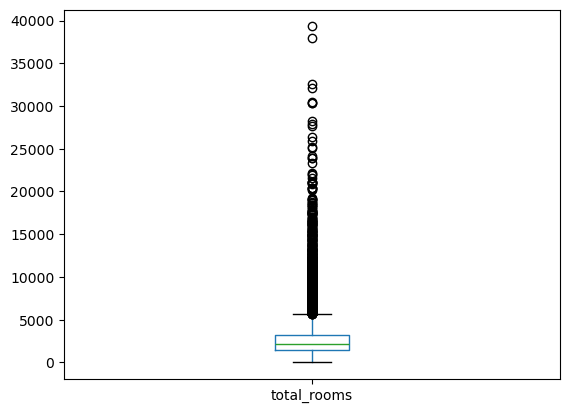

In [77]:
total_rooms.boxplot(grid=False)
plt.show()

- 데이터프레임 정규화: min-max 스케일링

In [78]:
minmax = (total_rooms - total_rooms.min()) / (total_rooms.max() - total_rooms.min())
minmax

,total_rooms
0,0.022331
1,0.180503
2,0.037260
3,0.032352
4,0.041330
...,...
20635,0.042296
20636,0.017676
20637,0.057277
20638,0.047256


min-max 스케일링 결과를 기술통계로 검증한다 (최솟값 0, 최댓값 1).

In [79]:
minmax.describe()

,total_rooms
count,20640.000000
mean,0.066986
std,0.055486
min,0.000000
25%,0.036771
50%,0.054046
75%,0.080014
max,1.000000


- 데이터프레임 정규화: 표준화

In [80]:
z = (total_rooms - total_rooms.mean()) / total_rooms.std(ddof=0)
z

,total_rooms
0,-0.804819
1,2.045890
2,-0.535746
3,-0.624215
4,-0.462404
...,...
20635,-0.444985
20636,-0.888704
20637,-0.174995
20638,-0.355600


표준화 결과를 기술통계로 검증한다 (평균 ≈ 0, 표준편차 = 1).

In [81]:
z.describe()

,total_rooms
count,2.064000e+04
mean,2.203233e-17
std,1.000024e+00
min,-1.207283e+00
25%,-5.445698e-01
50%,-2.332104e-01
75%,2.348028e-01
max,1.681558e+01


넘파이 어레이를 이용한 정규화도 물론 가능하다.

In [82]:
total_rooms_arr = total_rooms.values
total_rooms_arr.shape

(20640, 1)

- 어레이 정규화: min-max 스케일링

In [83]:
minmax_arr = (total_rooms_arr - np.min(total_rooms_arr)) / (np.max(total_rooms_arr) - np.min(total_rooms_arr))
minmax_arr

array([[0.02233074],
       [0.18050257],
       [0.03726029],
       ...,
       [0.05727657],
       [0.04725571],
       [0.07078183]], shape=(20640, 1))

어레이 min-max 스케일링 결과의 최솟값이 0인지 확인한다.

In [84]:
np.min(minmax_arr)

np.float64(0.0)

최댓값이 1인지 확인한다.

In [85]:
np.max(minmax_arr)

np.float64(1.0)

- 어레이 정규화: 표준화

In [86]:
z_arr = (total_rooms_arr - np.mean(total_rooms_arr)) / np.std(total_rooms_arr)
z_arr

array([[-0.8048191 ],
       [ 2.0458901 ],
       [-0.53574589],
       ...,
       [-0.17499526],
       [-0.35559977],
       [ 0.06840827]], shape=(20640, 1))

표준화된 어레이의 평균값을 확인한다 (0에 근접해야 함).

In [87]:
np.mean(z_arr)

np.float64(2.2032332891786052e-17)

In [88]:
np.std(z_arr)

np.float64(1.0)